# Preprocesamiento de los datos de Maching Learning
Aplicar las tecnicas principales de preprocesamiento de datos para recuperar un datasetantes del entrenamiento

## Parte 1. Comprensión del problema

Trabajeremos con el Dataset de Titanic, para construir un modelo que sea capaz de
predecir si una persona sobrevive o no.


In [4]:
import pandas as pd
import numpy as np

#Librerias de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # <- ¡Asegúrate de que tenga la 'd'!
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

In [3]:
import os

# 1. Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("rahulsah06/titanic")
print("El dataset se descargó en:", path)

# 2. Cargar el archivo de entrenamiento (train.csv)
df = pd.read_csv(os.path.join(path, "train.csv"))

# 3. Mostrar las primeras 5 filas para comprobar que todo esté en orden
df.head()

100%|██████████| 34.1k/34.1k [00:00<00:00, 199kB/s]

Extracting files...


El dataset se descargó en: C:\Users\100043016\.cache\kagglehub\datasets\rahulsah06\titanic\versions\1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# descargamos el dataset de la pagina kaggle
# Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path  # Imprimimos la ruta

100%|██████████| 22.0k/22.0k [00:00<00:00, 257kB/s]

Extracting files...


'C:\\Users\\100043016\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [6]:
# Creamos el Dataframe
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [7]:
# Mostramos las primeras 5 filas
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Parte 2 Seleccion de Variables Predictoras y la Variable Objetivo
La variable objetivo sera: survived
donde 0 = No sobrevivio 1 = sobrevivio

In [9]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [11]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [12]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipotesis
Vamos a identificar la relacion entre variables numericas.
nota: la correlacion NO representa la importancia REAL de la variable en el modelo

In [30]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Age"
    "Parch",
    "Fare"
]

In [18]:
# Creamos la matriz de correlación
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


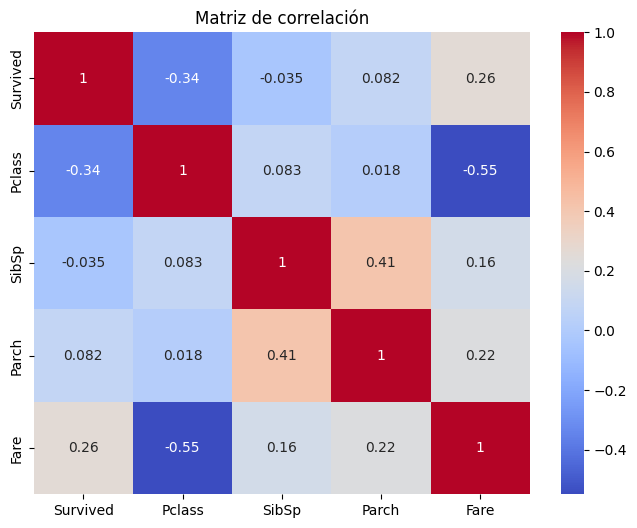

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

## Parte 4. Variables Predictoras

X --> Aquellas variables que nos ayudan a predecir
Y --> Variable Objetivo

In [22]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [26]:
# 2. Asignamos las variables independientes a X y la variable objetivo a y
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [32]:
# 1. Definimos la lista de columnas numéricas que usaremos como características (Features)
columnas = ["Pclass", "SibSp", "Parch", "Age", "Fare"]

In [27]:
y.name #Objetivo

'Survived'

## Parte 5. Limpieza de datos

Realizaremos la imputacion de los datos, donde existan valores nulos.

In [33]:
X.isnull().sum()

Pclass    0
SibSp     0
Parch     0
Fare      0
dtype: int64

In [35]:
# Rellenamos los nulos de la edad con la mediana directamente en el dataset original
dfTitanic["Age"] = dfTitanic["Age"].fillna(dfTitanic["Age"].median())

# Verificamos rápidamente que ya no haya nulos en 'Age'
print("Nulos en Age:", dfTitanic["Age"].isnull().sum())

Nulos en Age: 0


In [36]:
# Incluimos 'Age' dentro de las características para el modelo
columnas = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

# Volvemos a definir X e y con la columna integrada
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

# Comprobamos las dimensiones
print(f"Nuevas dimensiones de X: {X.shape}")

Nuevas dimensiones de X: (891, 5)


In [38]:
# Vamos a imputar los datos para el campo Edad, calculando la mediana en el DataFrame original
dfTitanic["Age"] = dfTitanic["Age"].fillna(dfTitanic["Age"].median())

In [39]:
# Vamos a imputar los datos para el campo Embarked, calculando la moda en el DataFrame original
dfTitanic["Embarked"] = dfTitanic["Embarked"].fillna(dfTitanic["Embarked"].mode()[0])

In [40]:
# Validamos rápidamente que ya no queden valores nulos en estas columnas
print("Nulos en Age:", dfTitanic["Age"].isnull().sum())
print("Nulos en Embarked:", dfTitanic["Embarked"].isnull().sum())

Nulos en Age: 0
Nulos en Embarked: 0


# Parte 6 normalizamos los datos categoricos (texto)
los algoritmos de ML no entienden texto

In [41]:
X.head(2)

,Pclass,Age,SibSp,Parch,Fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833


In [43]:
# Definimos las columnas originales que queremos (incluyendo las de texto)
columnas_totales = ["Pclass", "Sex", "Age", "Fare", "Embarked"]

In [44]:
# Reiniciamos la variable X tomándolas del DataFrame original limpio
X = dfTitanic[columnas_totales]

In [45]:
# Aplicamos el One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True
)

In [46]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


# Parte 7. Division de los datos
no debemos entrenar y evaluar utilizando los mismos datos
80% para entrenar
20% para evaluar

In [52]:

# 2. Dividimos el dataset en conjuntos de entrenamiento (Train) y prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
y = dfTitanic["Survived"]

In [53]:
# [29]: Imprimir las dimensiones del conjunto de entrenamiento X
print("Entrenamiento X: ", X_train.shape)

# [30]: Imprimir las dimensiones del conjunto de prueba X
print("Prueba X: ", X_test.shape)

# [31]: Imprimir las dimensiones del conjunto de entrenamiento Y
print("Entrenamiento Y: ", y_train.shape)

# [32]: Imprimir las dimensiones del conjunto de prueba Y
print("Prueba Y: ", y_test.shape)

Entrenamiento X:  (712, 6)
Prueba X:  (179, 6)
Entrenamiento Y:  (712,)
Prueba Y:  (179,)
